# Тестирование задач 13-15

Этот ноутбук тестирует реализацию оценки входящих данных для optimizer на основе исторических β.

**Задача 13**: Рассчитать ковариационную матрицу на основе исторических β

**Задача 14**: Построить границу эффективных портфелей на основе полученной ковариационной матрицы

**Задача 15**: Построить границу эффективных портфелей для разных исторических окон

Выбор из задач 11-12:
- Индекс: IMOEX (Мосбиржа)
- Окно: Скользящее окно длиной в 1 год (252 торговых дня)
- Схема взвешивания: Равные веса наблюдений

In [6]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from task_13_14_15 import (
    calculate_market_model_betas,
    calculate_all_betas,
    calculate_covariance_from_betas,
    calculate_residual_variances,
    task_13_covariance_from_historical_betas,
    task_14_efficient_frontier_from_betas,
    task_15_efficient_frontier_dynamics_betas,
    compare_covariance_methods
)

# Настройка графиков
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

pd.set_option('display.max_columns', 15)
pd.set_option('display.width', 120)

## 1. Загрузка данных

In [7]:
def preprocess_data(df: pd.DataFrame) -> pd.DataFrame:
    
    df.columns = df.columns.str.strip()
    df['date'] = pd.to_datetime(df['date'], format='%d.%m.%Y')
    df.set_index('date', inplace=True)

    df = df.replace('', np.nan).replace(' ', np.nan) \
            .dropna(how='all') \
            .dropna(axis=1, how='all')
    
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df

In [8]:
def load_prices_data(file_path: str) -> pd.DataFrame:
    df = pd.read_csv(file_path, sep=';', decimal=',')

    return preprocess_data(df)

In [9]:
# Импорт функций загрузки из task_2_3
sys.path.insert(0, '../task-2-3')
from task_2_3 import calculate_returns

# Загрузка данных
prices = load_prices_data('../data/prices_moex_new.csv')

print("=== Информация о данных ===")
print(f"Размер: {prices.shape}")
print(f"Период: {prices.index.min()} - {prices.index.max()}")
print(f"Количество акций: {len(prices.columns)}")
print(f"\nСписок акций: {list(prices.columns)}")

=== Информация о данных ===
Размер: (2763, 30)
Период: 2015-01-05 00:00:00 - 2025-12-30 00:00:00
Количество акций: 30

Список акций: ['SBER', 'SBERP', 'GAZP', 'LKOH', 'ROSN', 'NVTK', 'TATN', 'TATNP', 'SNGS', 'SNGSP', 'GMKN', 'CHMF', 'NLMK', 'MAGN', 'MTSS', 'AFLT', 'VTBR', 'MOEX', 'PLZL', 'ALRS', 'MGNT', 'PHOR', 'AKRN', 'FEES', 'HYDR', 'IRAO', 'BSPB', 'TRNFP', 'SIBN', 'LSRG']


## 2. Расчет доходностей

In [10]:
# Расчет логарифмических доходностей
returns = calculate_returns(prices)

print("=== Информация о доходностях ===")
print(f"Размер: {returns.shape}")
print(f"Период: {returns.index.min()} - {returns.index.max()}")
print(f"\nПервые 5 строк:")
print(returns.head())

=== Информация о доходностях ===
Размер: (2715, 30)
Период: 2015-01-21 00:00:00 - 2025-12-30 00:00:00

Первые 5 строк:
                SBER     SBERP      GAZP      LKOH      ROSN      NVTK      TATN  ...      FEES      HYDR      IRAO  \
date                                                                              ...                                 
2015-01-21  0.032365  0.024554  0.020710  0.045838  0.032932  0.031907  0.067695  ...  0.008243  0.036368  0.025975   
2015-01-22  0.024382  0.034286  0.017983  0.024409  0.030229  0.065698  0.043756  ...  0.004761  0.017700  0.012739   
2015-01-23  0.001553  0.025128  0.008741  0.010231  0.008647 -0.022594  0.036399  ... -0.012043 -0.017700  0.000000   
2015-01-26 -0.063412 -0.068931 -0.032114  0.005565 -0.027644 -0.015748 -0.042158  ... -0.029270 -0.036368 -0.065383   
2015-01-27  0.011669  0.021228  0.019405  0.020795  0.007349  0.002972  0.041991  ... -0.002975  0.018349 -0.013606   

                BSPB     TRNFP      SIBN      L

## 3. Тестирование рыночной модели

In [11]:
# Проверка функции расчета бета для одной акции
print("=== Тестирование рыночной модели ===")

# Используем первую акцию и индекс MOEX
test_ticker = returns.columns[0]
market_ticker = 'MOEX'

alpha, beta = calculate_market_model_betas(returns[test_ticker], returns[market_ticker])

print(f"Акция: {test_ticker}")
print(f"Рыночный индекс: {market_ticker}")
print(f"α (альфа): {alpha:.6f}")
print(f"β (бета): {beta:.6f}")

# Интерпретация бета
if beta > 1:
    beta_interp = "агрессивная (более волатильна, чем рынок)"
elif beta > 0:
    beta_interp = "защитная (менее волатильна, чем рынок)"
elif beta < 0:
    beta_interp = "противоположная рынку"
else:
    beta_interp = "без корреляции с рынком"

print(f"Интерпретация: {beta_interp}")

=== Тестирование рыночной модели ===
Акция: SBER
Рыночный индекс: MOEX
α (альфа): 0.000398
β (бета): 0.620084
Интерпретация: защитная (менее волатильна, чем рынок)


## 4. Расчет бета для всех акций

In [12]:
# Расчет бета для всех акций относительно индекса MOEX
print("=== Расчет бета для всех акций ===")

betas = calculate_all_betas(returns, market_ticker='MOEX')

print(f"\nРассчитано {len(betas)} бета-коэффициентов")
print(f"\nБета-коэффициенты (все акции):")
print(betas)

# Статистика
print(f"\n=== Статистика бета ===")
print(f"Среднее: {betas['beta'].mean():.4f}")
print(f"Стд. отклонение: {betas['beta'].std():.4f}")
print(f"Минимум: {betas['beta'].min():.4f} ({betas['beta'].idxmin()})")
print(f"Максимум: {betas['beta'].max():.4f} ({betas['beta'].idxmax()})")

# Классификация по бета
defensive = betas[betas['beta'] < 1].index
aggressive = betas[betas['beta'] > 1].index

print(f"\nЗащитные акции (β < 1): {len(defensive)}")
print(f"Агрессивные акции (β > 1): {len(aggressive)}")

=== Расчет бета для всех акций ===

Рассчитано 29 бета-коэффициентов

Бета-коэффициенты (все акции):
           alpha      beta
ticker                    
SBER    0.000398  0.620084
SBERP   0.000539  0.573644
GAZP   -0.000198  0.487007
LKOH    0.000146  0.441565
ROSN    0.000028  0.526655
NVTK    0.000139  0.490157
TATN    0.000111  0.522170
TATNP   0.000375  0.448840
SNGS   -0.000233  0.523948
SNGSP  -0.000140  0.315390
GMKN    0.000028  0.396961
CHMF    0.000175  0.421166
NLMK    0.000073  0.413622
MAGN    0.000232  0.442444
MTSS   -0.000050  0.378461
AFLT    0.000096  0.510874
VTBR   -0.000703  0.563837
PLZL    0.000966  0.286538
ALRS   -0.000351  0.454672
MGNT   -0.000616  0.419681
PHOR    0.000203  0.164141
AKRN    0.000629  0.137950
FEES   -0.000065  0.505176
HYDR   -0.000194  0.399769
IRAO    0.000395  0.497865
BSPB    0.000900  0.380512
TRNFP  -0.000003  0.385883
SIBN    0.000349  0.395685
LSRG    0.000049  0.369059

=== Статистика бета ===
Среднее: 0.4301
Стд. отклонение: 0.10

## 5. Визуализация бета

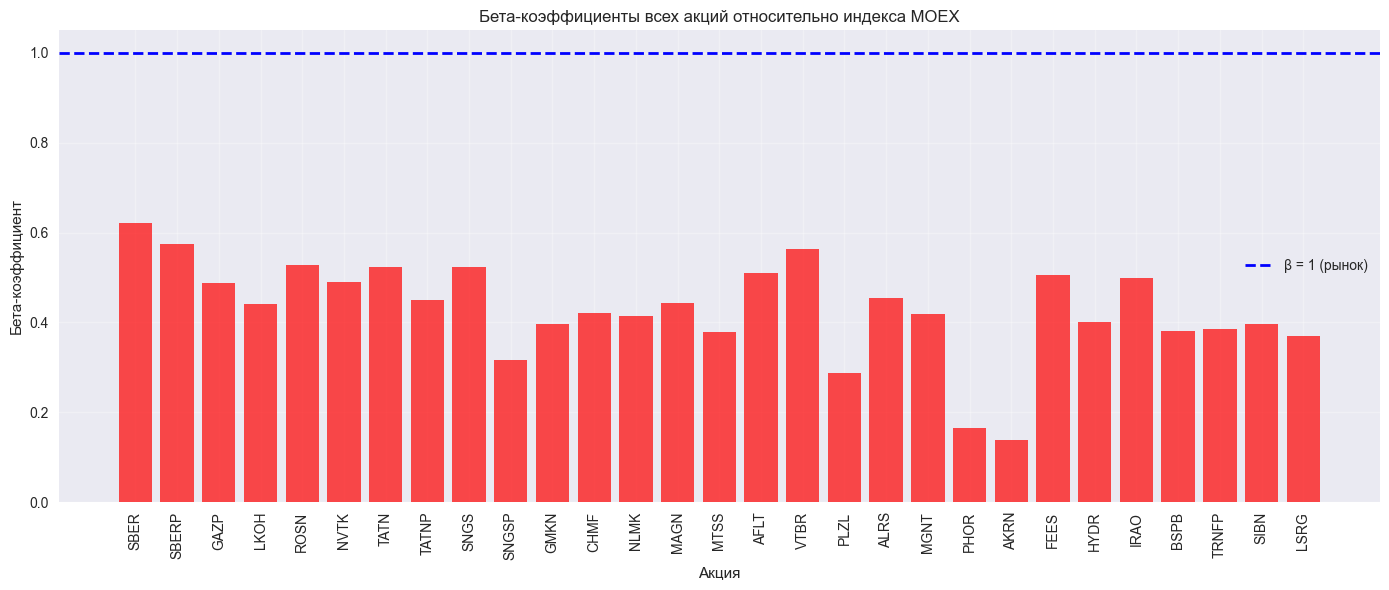

In [13]:
# График бета-коэффициентов
plt.figure(figsize=(14, 6))

colors = ['red' if b < 1 else 'green' for b in betas['beta']]
plt.bar(range(len(betas)), betas['beta'], color=colors, alpha=0.7)
plt.axhline(y=1, color='blue', linestyle='--', linewidth=2, label='β = 1 (рынок)')
plt.xticks(range(len(betas)), betas.index, rotation=90)
plt.xlabel('Акция')
plt.ylabel('Бета-коэффициент')
plt.title('Бета-коэффициенты всех акций относительно индекса MOEX')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Задача 13: Ковариационная матрица на основе исторических β

In [14]:
# Задача 13: Расчет ковариационной матрицы на основе исторических β
print("=== Задача 13 ===")

betas_result = task_13_covariance_from_historical_betas(
    returns, market_ticker='MOEX', include_residuals=True
)

=== Задача 13 ===
Задача 13: Расчет ковариационной матрицы на основе исторических β...
Рыночный индекс: MOEX
Учет остаточных дисперсий: True

Рассчитано 29 бета-коэффициентов
Бета-коэффициенты:
ticker
SBER     0.620084
SBERP    0.573644
GAZP     0.487007
LKOH     0.441565
ROSN     0.526655
NVTK     0.490157
TATN     0.522170
TATNP    0.448840
SNGS     0.523948
SNGSP    0.315390
Name: beta, dtype: float64
...
Средняя бета: 0.4301
Стд. отклонение бета: 0.1086

Дисперсия рынка: 0.000329
Учет остаточных дисперсий
Средняя остаточная дисперсия: 0.000449

Размер ковариационной матрицы: (29, 29)
Среднее значение (бета-модель): 0.000076
Среднее значение (классическая): 0.000178
✓ Ковариационная матрица положительно определена


In [15]:
# Сравнение ковариационных матриц
print("\n=== Сравнение ковариационных матриц ===")

stock_tickers = [col for col in returns.columns if col != 'MOEX']

cov_classic = returns[stock_tickers].cov()
cov_beta = pd.DataFrame(
    betas_result['cov_matrix'],
    index=stock_tickers,
    columns=stock_tickers
)

print(f"\nКлассическая ковариационная матрица (первые 5x5):")
print(cov_classic.iloc[:5, :5])

print(f"\nКовариационная матрица на основе β (первые 5x5):")
print(cov_beta.iloc[:5, :5])

# Разность
diff = (cov_classic - cov_beta).abs()
print(f"\nАбсолютная разность (первые 5x5):")
print(diff.iloc[:5, :5])
print(f"\nСредняя разность: {diff.mean().mean():.6f}")


=== Сравнение ковариационных матриц ===

Классическая ковариационная матрица (первые 5x5):
           SBER     SBERP      GAZP      LKOH      ROSN
SBER   0.000467  0.000409  0.000268  0.000231  0.000292
SBERP  0.000409  0.000406  0.000243  0.000204  0.000270
GAZP   0.000268  0.000243  0.000458  0.000220  0.000265
LKOH   0.000231  0.000204  0.000220  0.000363  0.000269
ROSN   0.000292  0.000270  0.000265  0.000269  0.000427

Ковариационная матрица на основе β (первые 5x5):
           SBER     SBERP      GAZP      LKOH      ROSN
SBER   0.000467  0.000117  0.000099  0.000090  0.000108
SBERP  0.000117  0.000406  0.000092  0.000083  0.000099
GAZP   0.000099  0.000092  0.000458  0.000071  0.000084
LKOH   0.000090  0.000083  0.000071  0.000363  0.000077
ROSN   0.000108  0.000099  0.000084  0.000077  0.000427

Абсолютная разность (первые 5x5):
               SBER         SBERP      GAZP      LKOH          ROSN
SBER   5.421011e-20  2.916835e-04  0.000169  0.000141  1.839794e-04
SBERP  2.916835

## 7. Задача 14: Эффективная граница на основе β

In [16]:
# Задача 14: Эффективная граница на основе ковариационной матрицы из β
print("=== Задача 14 ===")

stock_returns = returns[stock_tickers]
mean_returns = stock_returns.mean().values

ef_returns, ef_stds = task_14_efficient_frontier_from_betas(
    betas_result['cov_matrix'],
    mean_returns,
    n_points=50,
    method_name="Исторические β"
)

=== Задача 14 ===

Задача 14: Построение эффективной границы на основе Исторические β...
Эффективная граница: 50 точек
Мин. доходность: 0.000323, Стд: 0.007431
Макс. доходность: 0.001076, Стд: 0.010953
Макс. Шарп-отношение: 0.098230
При доходности: 0.001076, риске: 0.010953


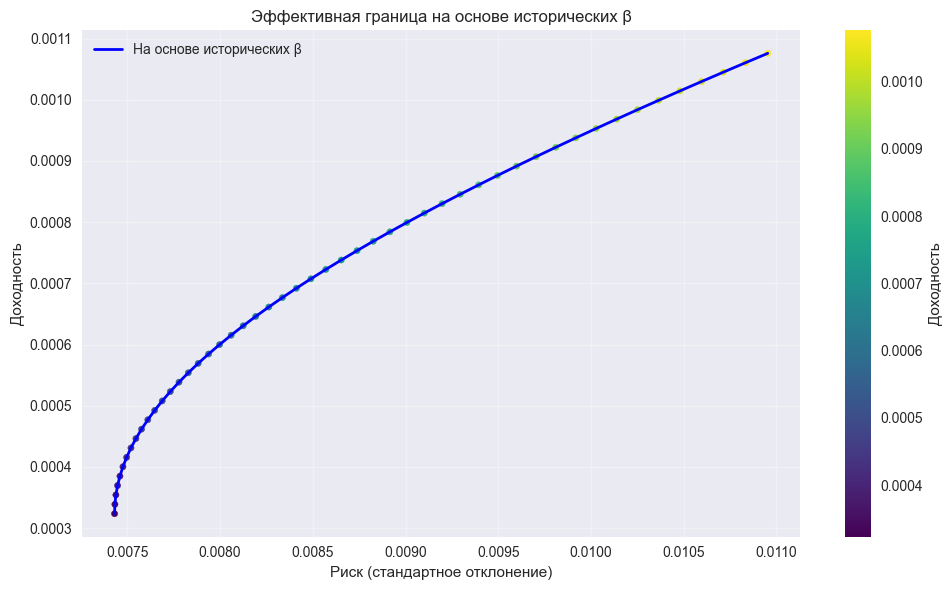

In [17]:
# Визуализация эффективной границы
plt.figure(figsize=(10, 6))
plt.plot(ef_stds, ef_returns, 'b-', linewidth=2, label='На основе исторических β')
plt.scatter(ef_stds, ef_returns, c=ef_returns, cmap='viridis', s=20)
plt.colorbar(label='Доходность')
plt.xlabel('Риск (стандартное отклонение)')
plt.ylabel('Доходность')
plt.title('Эффективная граница на основе исторических β')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Задача 15: Динамика эффективных границ на основе β

In [18]:
# Задача 15: Динамика эффективных границ на основе β
print("=== Задача 15 ===")

beta_frontiers, beta_stability = task_15_efficient_frontier_dynamics_betas(
    returns, market_ticker='MOEX', window_size='1Y', step_size='1Y',
    include_residuals=True, n_points=50
)

=== Задача 15 ===
Задача 15: Динамика эффективных границ на основе исторических β
Окно: 1Y, Шаг: 1Y
Получено окон: 10
Рассчитано эффективных границ: 10
Рассчитаны метрики стабильности


In [19]:
# Метрики стабильности
print("=== Метрики стабильности ===")
print(beta_stability)

=== Метрики стабильности ===
             min_std  min_std_return  max_return  max_return_std  max_sharpe  max_sharpe_return  max_sharpe_std  \
date                                                                                                              
2016-01-21  0.005441        0.000689    0.004085        0.013257    0.308151           0.004085        0.013257   
2017-01-20  0.003622        0.001276    0.005211        0.009917    0.552947           0.003123        0.005648   
2018-01-20  0.004248       -0.000031    0.002384        0.008873    0.268672           0.002384        0.008873   
2019-01-20  0.003874        0.000143    0.001893        0.006860    0.275935           0.001893        0.006860   
2020-01-20  0.002544        0.000534    0.002614        0.007249    0.371433           0.001680        0.004524   
2021-01-19  0.005760        0.000783    0.002754        0.010110    0.272370           0.002754        0.010110   
2022-01-19  0.004949       -0.000212    0.002725   

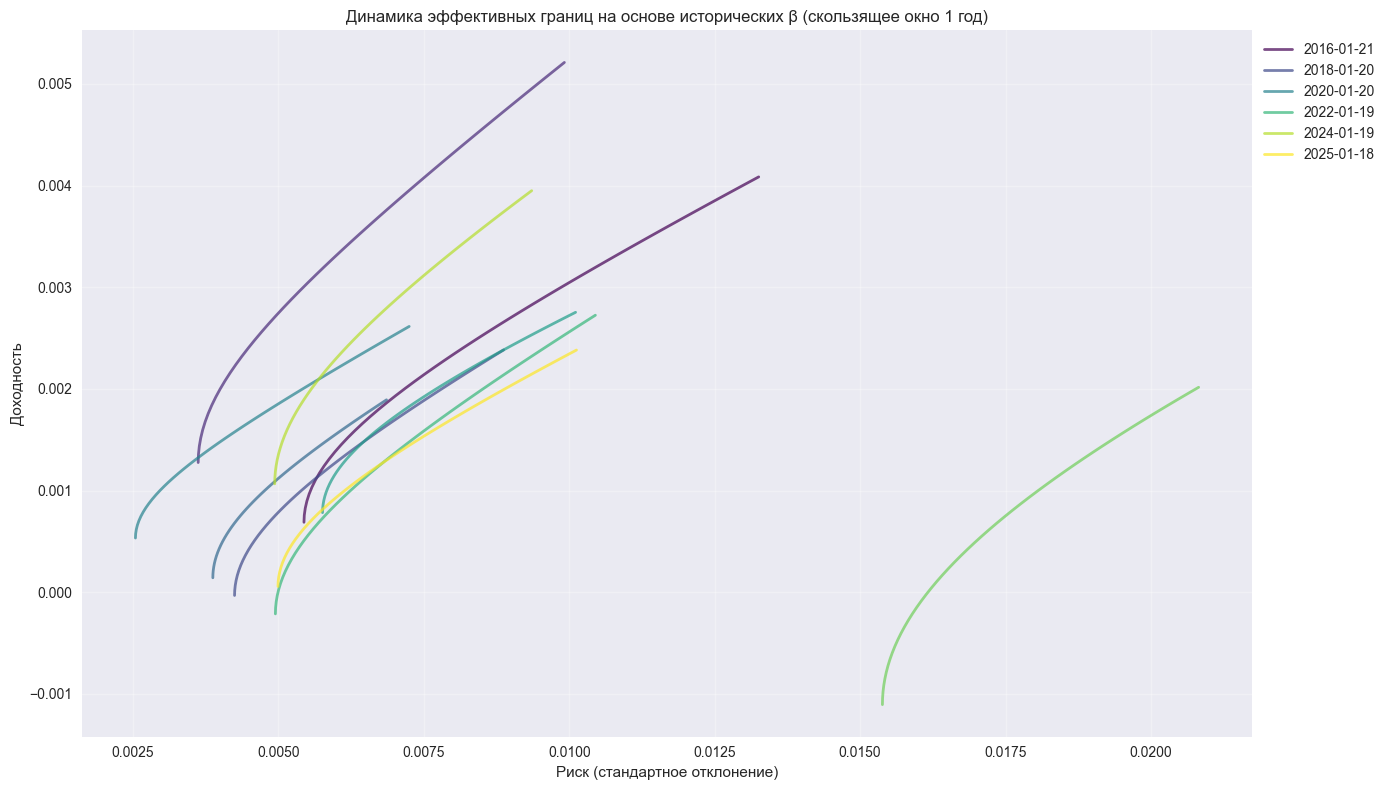

In [20]:
# Визуализация эффективных границ для всех окон
plt.figure(figsize=(14, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(beta_frontiers)))

for i, (date, frontier) in enumerate(sorted(beta_frontiers.items())):
    label = date.strftime('%Y-%m-%d') if i % 2 == 0 or i == len(beta_frontiers) - 1 else None
    plt.plot(frontier['stds'], frontier['returns'], 
             color=colors[i], linewidth=2, alpha=0.7, label=label)

plt.xlabel('Риск (стандартное отклонение)')
plt.ylabel('Доходность')
plt.title('Динамика эффективных границ на основе исторических β (скользящее окно 1 год)')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

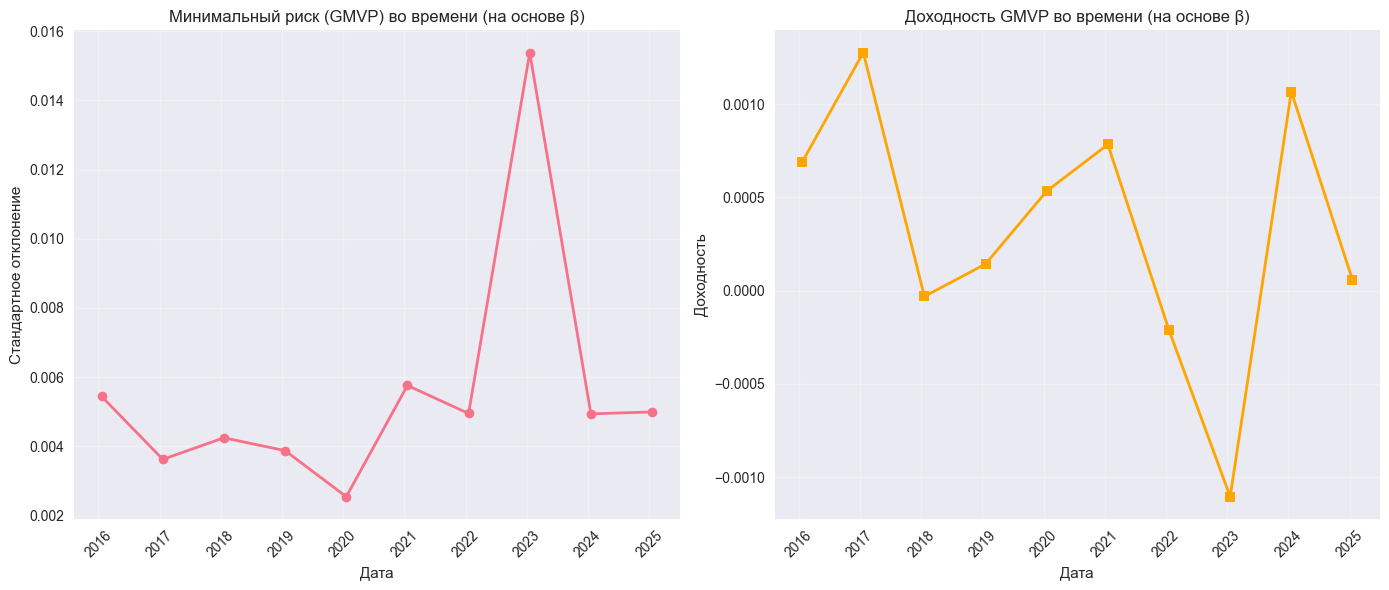

In [21]:
# График динамики минимального риска во времени
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(beta_stability.index, beta_stability['min_std'], marker='o', linewidth=2)
plt.title('Минимальный риск (GMVP) во времени (на основе β)')
plt.xlabel('Дата')
plt.ylabel('Стандартное отклонение')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.plot(beta_stability.index, beta_stability['min_std_return'], marker='s', linewidth=2, color='orange')
plt.title('Доходность GMVP во времени (на основе β)')
plt.xlabel('Дата')
plt.ylabel('Доходность')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

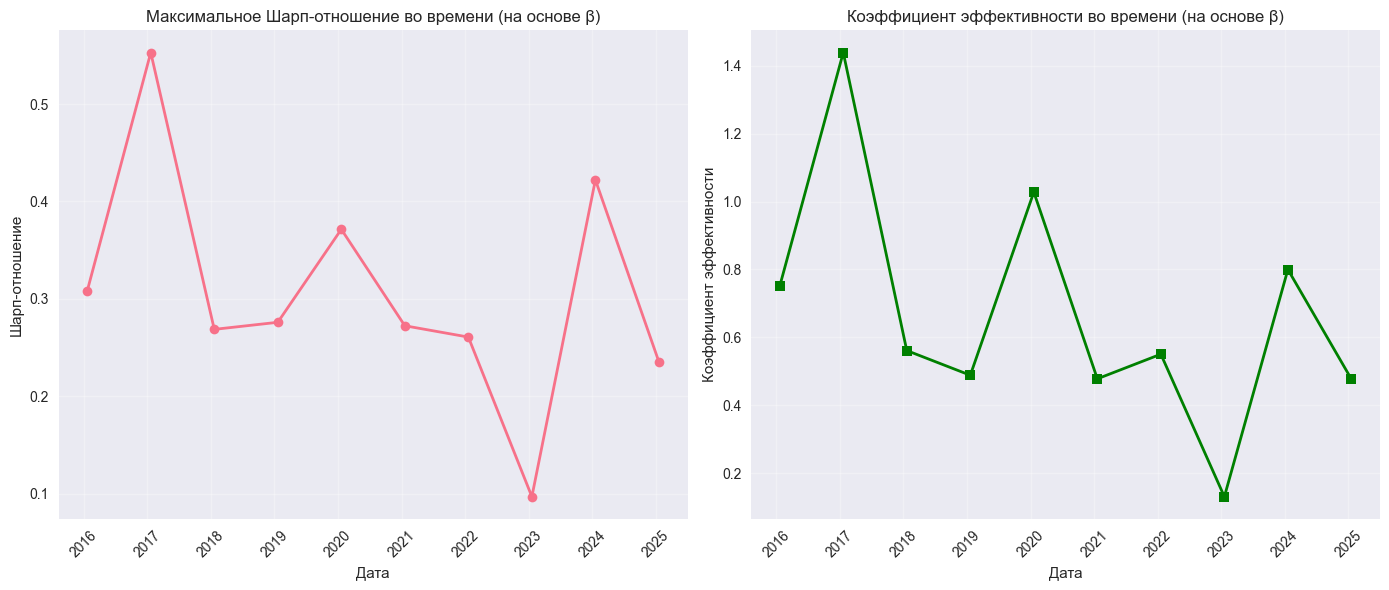

In [22]:
# График динамики максимального Шарпа во времени
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(beta_stability.index, beta_stability['max_sharpe'], marker='o', linewidth=2)
plt.title('Максимальное Шарп-отношение во времени (на основе β)')
plt.xlabel('Дата')
plt.ylabel('Шарп-отношение')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
plt.plot(beta_stability.index, beta_stability['efficiency_ratio'], marker='s', linewidth=2, color='green')
plt.title('Коэффициент эффективности во времени (на основе β)')
plt.xlabel('Дата')
plt.ylabel('Коэффициент эффективности')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 9. Сравнение методов расчета ковариационных матриц

In [23]:
# Сравнение трех методов
print("=== Сравнение методов расчета ковариационных матриц ===")

comparison = compare_covariance_methods(returns, market_ticker='MOEX')

=== Сравнение методов расчета ковариационных матриц ===
=== Сравнение методов расчета ковариационных матриц ===
Задача 13: Расчет ковариационной матрицы на основе исторических β...
Рыночный индекс: MOEX
Учет остаточных дисперсий: False

Рассчитано 29 бета-коэффициентов
Бета-коэффициенты:
ticker
SBER     0.620084
SBERP    0.573644
GAZP     0.487007
LKOH     0.441565
ROSN     0.526655
NVTK     0.490157
TATN     0.522170
TATNP    0.448840
SNGS     0.523948
SNGSP    0.315390
Name: beta, dtype: float64
...
Средняя бета: 0.4301
Стд. отклонение бета: 0.1086

Дисперсия рынка: 0.000329

Размер ковариационной матрицы: (29, 29)
Среднее значение (бета-модель): 0.000061
Среднее значение (классическая): 0.000178
⚠ Ковариационная матрица не положительно определена
✓ Добавлена регуляризация
Задача 13: Расчет ковариационной матрицы на основе исторических β...
Рыночный индекс: MOEX
Учет остаточных дисперсий: True

Рассчитано 29 бета-коэффициентов
Бета-коэффициенты:
ticker
SBER     0.620084
SBERP    0.57

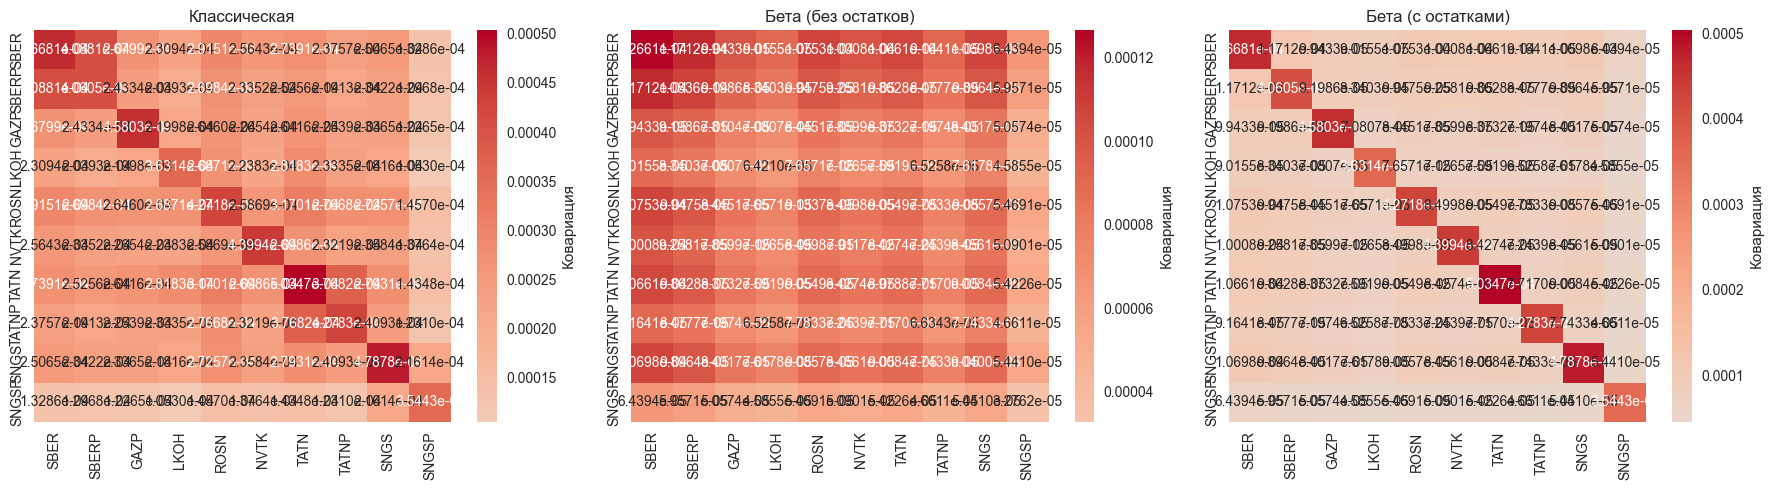

In [24]:
# Визуальное сравнение тепловых карт ковариационных матриц
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

methods = [('Классическая', comparison['classic']), 
           ('Бета (без остатков)', comparison['beta_simple']),
           ('Бета (с остатками)', comparison['beta_residuals'])]

for idx, (title, matrix) in enumerate(methods):
    sns.heatmap(matrix[:10, :10], ax=axes[idx], annot=True, fmt='.4e',
                cmap='coolwarm', center=0, cbar_kws={'label': 'Ковариация'})
    axes[idx].set_title(title)
    axes[idx].set_xticklabels(stock_tickers[:10], rotation=90)
    axes[idx].set_yticklabels(stock_tickers[:10])

plt.tight_layout()
plt.show()

## 10. Итоговый анализ

In [25]:
print("=== Итоговый анализ ===")
print(f"\nПериод данных: {returns.index.min()} - {returns.index.max()}")
print(f"Всего наблюдений: {len(returns)}")
print(f"Количество акций: {len(stock_tickers)}")
print(f"Рыночный индекс: MOEX")

print(f"\n--- Бета-коэффициенты ---")
print(f"Средняя бета: {betas_result['betas'].mean():.4f}")
print(f"Стд. отклонение бета: {betas_result['betas'].std():.4f}")
print(f"Дисперсия рынка: {betas_result['market_variance']:.6f}")

print(f"\n--- Задача 15: Динамика ---")
print(f"Получено окон: {len(beta_frontiers)}")
print(f"Средний минимальный риск: {beta_stability['min_std'].mean():.6f}")
print(f"Средний макс. Шарп: {beta_stability['max_sharpe'].mean():.6f}")

print(f"\n--- Сравнение методов ---")
print(f"Классическая матрица - среднее: {comparison['classic'].mean():.6f}")
print(f"Бета (без остатков) - среднее: {comparison['beta_simple'].mean():.6f}")
print(f"Бета (с остатками) - среднее: {comparison['beta_residuals'].mean():.6f}")

=== Итоговый анализ ===

Период данных: 2015-01-21 00:00:00 - 2025-12-30 00:00:00
Всего наблюдений: 2715
Количество акций: 29
Рыночный индекс: MOEX

--- Бета-коэффициенты ---
Средняя бета: 0.4301
Стд. отклонение бета: 0.1086
Дисперсия рынка: 0.000329

--- Задача 15: Динамика ---
Получено окон: 10
Средний минимальный риск: 0.005575
Средний макс. Шарп: 0.306459

--- Сравнение методов ---
Классическая матрица - среднее: 0.000178
Бета (без остатков) - среднее: 0.000061
Бета (с остатками) - среднее: 0.000076


## Вывод

В этом ноутбуке мы протестировали:
1. Расчет параметров рыночной модели (α и β)
2. Расчет бета-коэффициентов для всех акций относительно индекса MOEX
3. Задачу 13: Расчет ковариационной матрицы на основе исторических β
4. Задачу 14: Построение эффективной границы на основе β
5. Задачу 15: Динамику эффективных границ на основе β
6. Сравнение различных методов расчета ковариационных матриц

Все функции работают корректно и позволяют анализировать портфели с использованием рыночной модели.